# Pareto Frontier Analysis for Diversified QUBO Portfolio Optimization

This notebook explores the Pareto frontier by varying the risk aversion parameter in diversified (restricted) QUBO-based portfolio optimization on the wide dataset (680 assets).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline,
    genetic_algorithm_qubo,
    scipy_slsqp_qubo,
    riskfolio_qubo,
    portfolio_stats
)
from analysis_utils import (
    write_pickle_dict,
    read_pickle_dict,
    plot_pareto_frontier,
    compare_pareto_frontiers,
    plot_weight_evolution,
    extract_pareto_frontier
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Create a logger
logger = logging.getLogger("pareto_logger")
logger.setLevel(msg_level)

## Data Paths

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'
source_path_extended = '../../data/etfs_close.pkl'
results_base_path = '../../results/pareto_optimization_diversified/'

## Data Loading

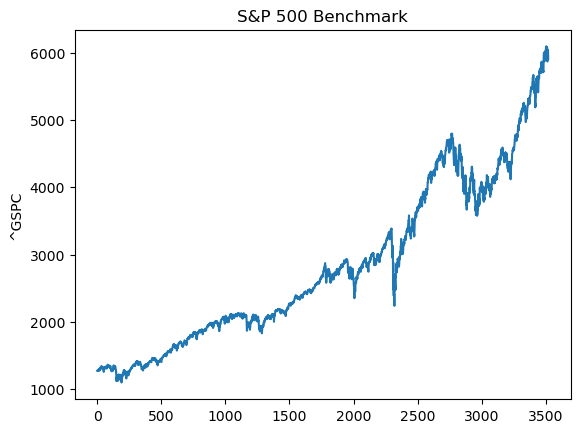

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
plt.title('S&P 500 Benchmark')
plt.show()
benchmark.head()

In [5]:
source_extended = pd.read_pickle(source_path_extended)
print(f"Extended data shape: {source_extended.shape}")
source_extended.head()

Extended data shape: (3521, 242)


Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [6]:
source = pd.read_pickle(source_path)
print(f"Source data shape: {source.shape}")
has_any_nan = source.isnull().values.any()
print(f"Any NaN in source: {has_any_nan}")

Source data shape: (3522, 439)
Any NaN in source: False


In [7]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(f"Wide dataset shape: {source_wide.shape}")
has_any_nan = source_wide.isnull().values.any()
print(f"Any NaN in source_wide: {has_any_nan}")
source_wide.head()

Wide dataset shape: (3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


## Parameters

In [8]:
parameters = {
    "n_periods": 10,  # Run 10 different time ranges
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "budget": 1_000_000,
    "days_to_avg": 30,  # 30-day averaging period
    "days_to_opt": 30,   # 30-day optimization/testing period
    # Risk levels for Pareto frontier exploration
    "risk_levels": [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]
}

print(f"Optimization Parameters:")
for key, value in parameters.items():
    print(f"  {key}: {value}")

Optimization Parameters:
  n_periods: 10
  population_size: 100
  num_generations: 100
  mutation_rate: 0.1
  elitism: 0.1
  budget: 1000000
  days_to_avg: 30
  days_to_opt: 30
  risk_levels: [0.05, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 3.0]


## Pareto Optimization Functions

In [9]:
def pareto_sweep(data, optimization_function, risk_levels, **opt_kwargs):
    """
    Perform Pareto frontier sweep by optimizing across multiple risk levels.
    
    Args:
        data: Stock price DataFrame
        optimization_function: Optimization function to use
        risk_levels: List of risk aversion parameters to explore
        **opt_kwargs: Additional arguments for optimization function
        
    Returns:
        results_dict: Dictionary mapping risk_level -> optimization results
    """
    results = {}
    
    for risk_level in risk_levels:
        print(f"\nOptimizing with risk_level = {risk_level:.3f}")
        start_time = time.time()
        
        try:
            # Optimize for this risk level
            weights = optimization_function(data, risk_level=risk_level, **opt_kwargs)
            
            # Calculate portfolio statistics
            port_return, port_vol = portfolio_stats(weights, data)
            
            # Store results
            results[risk_level] = {
                'weights': weights,
                'portfolio_return': port_return,
                'portfolio_risk': port_vol,
                'portfolio_variance': port_vol ** 2,
                'sharpe_ratio': port_return / port_vol if port_vol > 0 else 0,
                'execution_time': time.time() - start_time,
                'risk_level': risk_level
            }
            
            print(f"  Return: {port_return:.6f}, Risk: {port_vol:.6f}, "
                  f"Sharpe: {results[risk_level]['sharpe_ratio']:.4f}, "
                  f"Time: {results[risk_level]['execution_time']:.2f}s")
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            results[risk_level] = None
    
    return results

In [10]:
def get_period_data(data, benchmark, period, days_to_avg=30, days_to_opt=30, seed=SEED):
    """
    Get data for a specific period using the same approach as other optimization notebooks.
    
    Args:
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame  
        period: Period index (0-9 for 10 periods)
        days_to_avg: Number of days to use for averaging (30)
        days_to_opt: Number of days to use for optimization/testing (30)
        seed: Random seed
        
    Returns:
        df_avg: Data for 30-day averaging period
        df_opt: Data for 30-day optimization period
        df_b_avg: Benchmark for averaging period
        df_b_opt: Benchmark for optimization period
    """
    df2 = data.reset_index()
    benchmark2 = benchmark.reset_index()
    
    # Sample 100 different starting dates deterministically
    np.random.seed(seed)
    max_samples = 100
    valid_range = range(days_to_avg, len(df2) - days_to_avg - days_to_opt)
    sample_indices = np.random.choice(valid_range, size=min(max_samples, len(valid_range)), replace=False)
    
    # Get the specific period
    if period >= len(sample_indices):
        raise ValueError(f"Period {period} exceeds available samples ({len(sample_indices)})")
    
    idx = sample_indices[period]
    
    # Averaging period (30 days before idx)
    df_avg = df2.iloc[idx - days_to_avg:idx, :].set_index('ds')
    df_b_avg = benchmark2.iloc[idx - days_to_avg:idx, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    # Optimization period (30 days after idx)
    df_opt = df2.iloc[idx:idx + days_to_opt, :].set_index('ds')
    df_b_opt = benchmark2.iloc[idx:idx + days_to_opt, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    return df_avg, df_opt, df_b_avg, df_b_opt

## Wide Dataset Pareto Frontier (680 Assets) - All Periods

In [11]:
# Initialize storage for all periods
all_periods_results_wide = {
    'genetic_algorithm': {},
    'scipy_slsqp': {},
    'riskfolio': {}
}

print(f"\nRunning Pareto optimization for Wide Dataset across {parameters['n_periods']} time periods...")
print("=" * 80)


Running Pareto optimization for Wide Dataset across 10 time periods...


### Genetic Algorithm - Wide Dataset (All Periods)

In [12]:
for period in range(parameters['n_periods']):
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - Genetic Algorithm (Wide Dataset)")
    print(f"{'='*80}")
    
    results_path = results_base_path + f'pareto_wide_ga_period_{period}.pkl'
    
    if not os.path.exists(results_path):
        # Get period data
        df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
            source_wide, benchmark, period,
            days_to_avg=parameters['days_to_avg'],
            days_to_opt=parameters['days_to_opt']
        )
        print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
        print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
        
        # Run Pareto sweep on averaging data with diversified QUBO
        results = pareto_sweep(
            df_avg,
            genetic_algorithm_qubo_diversified,
            parameters['risk_levels'],
            population_size=parameters['population_size'],
            num_generations=parameters['num_generations'],
            mutation_rate=parameters['mutation_rate'],
            elitism=parameters['elitism'],
            budget=parameters['budget']
        )
        write_pickle_dict(results, results_path)
    else:
        print(f"Loading existing results for period {period}...")
        results = read_pickle_dict(results_path)
    
    all_periods_results_wide['genetic_algorithm'][period] = results

print(f"\n{'='*80}")
print("Genetic Algorithm - Wide Dataset Complete")
print(f"{'='*80}")


PERIOD 0 - Genetic Algorithm (Wide Dataset)
Averaging period: 2018-03-05 00:00:00 to 2018-04-16 00:00:00
Optimization period: 2018-04-17 00:00:00 to 2018-05-29 00:00:00


NameError: name 'genetic_algorithm_qubo_diversified' is not defined

### SciPy SLSQP - Wide Dataset (All Periods)

In [ ]:
for period in range(parameters['n_periods']):
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - SciPy SLSQP (Wide Dataset)")
    print(f"{'='*80}")
    
    results_path = results_base_path + f'pareto_wide_slsqp_period_{period}.pkl'
    
    if not os.path.exists(results_path):
        # Get period data
        df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
            source_wide, benchmark, period,
            days_to_avg=parameters['days_to_avg'],
            days_to_opt=parameters['days_to_opt']
        )
        print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
        print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
        
        # Run Pareto sweep on averaging data with diversified QUBO
        results = pareto_sweep(
            df_avg,
            scipy_slsqp_qubo_diversified,
            parameters['risk_levels'],
            budget=parameters['budget']
        )
        write_pickle_dict(results, results_path)
    else:
        print(f"Loading existing results for period {period}...")
        results = read_pickle_dict(results_path)
    
    all_periods_results_wide['scipy_slsqp'][period] = results

print(f"\n{'='*80}")
print("SciPy SLSQP - Wide Dataset Complete")
print(f"{'='*80}")

### Riskfolio - Wide Dataset (All Periods)

In [ ]:
for period in range(parameters['n_periods']):
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - Riskfolio (Wide Dataset)")
    print(f"{'='*80}")
    
    results_path = results_base_path + f'pareto_wide_riskfolio_period_{period}.pkl'
    
    if not os.path.exists(results_path):
        # Get period data
        df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
            source_wide, benchmark, period,
            days_to_avg=parameters['days_to_avg'],
            days_to_opt=parameters['days_to_opt']
        )
        print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
        print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
        
        # Run Pareto sweep on averaging data with diversified QUBO
        results = pareto_sweep(
            df_avg,
            riskfolio_qubo_diversified,
            parameters['risk_levels'],
            budget=parameters['budget']
        )
        write_pickle_dict(results, results_path)
    else:
        print(f"Loading existing results for period {period}...")
        results = read_pickle_dict(results_path)
    
    all_periods_results_wide['riskfolio'][period] = results

print(f"\n{'='*80}")
print("Riskfolio - Wide Dataset Complete")
print(f"{'='*80}")

### Aggregate Results - Wide Dataset

In [ ]:
# Aggregate results across all periods function
def aggregate_results(all_periods_dict):
    """Aggregate results across all periods for a given solver"""
    aggregated = {}
    
    # Get all risk levels from first period
    first_period = list(all_periods_dict.values())[0]
    risk_levels = list(first_period.keys())
    
    for risk_level in risk_levels:
        returns = []
        risks = []
        sharpes = []
        exec_times = []
        
        for period_results in all_periods_dict.values():
            if risk_level in period_results and period_results[risk_level] is not None:
                returns.append(period_results[risk_level]['portfolio_return'])
                risks.append(period_results[risk_level]['portfolio_risk'])
                sharpes.append(period_results[risk_level]['sharpe_ratio'])
                exec_times.append(period_results[risk_level]['execution_time'])
        
        if returns:  # Only create entry if we have data
            aggregated[risk_level] = {
                'portfolio_return': np.mean(returns),
                'portfolio_risk': np.mean(risks),
                'sharpe_ratio': np.mean(sharpes),
                'execution_time': np.mean(exec_times),
                'risk_level': risk_level,
                'return_std': np.std(returns),
                'risk_std': np.std(risks),
                'sharpe_std': np.std(sharpes),
                'n_periods': len(returns)
            }
    
    return aggregated

# Aggregate results for each solver
aggregated_ga_wide = aggregate_results(all_periods_results_wide['genetic_algorithm'])
aggregated_slsqp_wide = aggregate_results(all_periods_results_wide['scipy_slsqp'])
aggregated_riskfolio_wide = aggregate_results(all_periods_results_wide['riskfolio'])

# Plot aggregated Pareto frontiers
frontiers_wide = {
    'Genetic Algorithm': aggregated_ga_wide,
    'SciPy SLSQP': aggregated_slsqp_wide,
    'Riskfolio': aggregated_riskfolio_wide
}

compare_pareto_frontiers(frontiers_wide, title="Pareto Frontier Comparison - Diversified QUBO (Wide Dataset - 680 Assets, Averaged Across 10 Periods)")

# Print summary statistics
print("\n" + "=" * 80)
print("AGGREGATED RESULTS - DIVERSIFIED QUBO (Wide Dataset - 680 Assets)")
print("=" * 80)
for method, results in [('Genetic Algorithm', aggregated_ga_wide), 
                        ('SciPy SLSQP', aggregated_slsqp_wide),
                        ('Riskfolio', aggregated_riskfolio_wide)]:
    print(f"\n{method}:")
    if results:
        print(f"  Valid risk levels: {len(results)}/{len(parameters['risk_levels'])}")
        print(f"  Average execution time: {np.mean([r['execution_time'] for r in results.values()]):.2f}s")
    else:
        print("  No valid results")
print("=" * 80)

In [ ]:
# Plot weight evolution for aggregated SLSQP results
pareto_slsqp_wide = extract_pareto_frontier(aggregated_slsqp_wide)
if pareto_slsqp_wide:
    print(f"Pareto-optimal solutions (SLSQP - Wide): {len(pareto_slsqp_wide)}")
else:
    print("No Pareto-optimal solutions found for SLSQP (Wide Dataset)")

## Summary and Insights

In [ ]:
print("=" * 80)
print("PARETO FRONTIER ANALYSIS SUMMARY - DIVERSIFIED QUBO")
print("=" * 80)

print(f"\nAnalysis Configuration:")
print(f"  Optimization Type: Diversified (Restricted) QUBO")
print(f"  Number of periods: {parameters['n_periods']}")
print(f"  Days for averaging: {parameters['days_to_avg']}")
print(f"  Days for optimization/testing: {parameters['days_to_opt']}")
print(f"  Budget constraint: ${parameters['budget']:,.0f}")
print(f"  Risk levels tested: {parameters['risk_levels']}")

print("\nWide Dataset (680 Assets - Stocks + ETFs):")
for method, results in frontiers_wide.items():
    pareto = extract_pareto_frontier(results)
    print(f"  {method}: {len(pareto)} Pareto-optimal solutions (averaged across periods)")
